In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

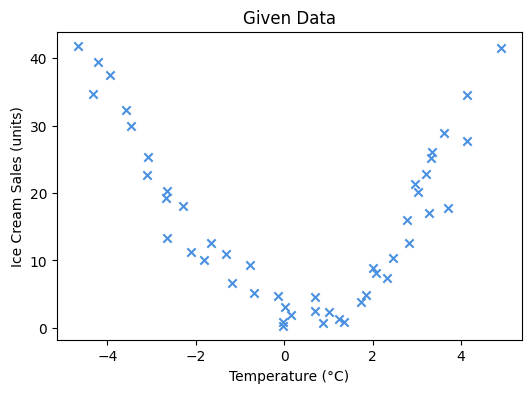

In [29]:
# Load and plot actual data

df = pd.read_csv("./Ice_cream selling data.csv")

X = df['Temperature (°C)']
Y = df['Ice Cream Sales (units)']

fig = plt.figure(figsize=(6,4))

plt.scatter(X, Y, marker='x', color='#4A90E2')
plt.title("Given Data")
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units)')
plt.show()

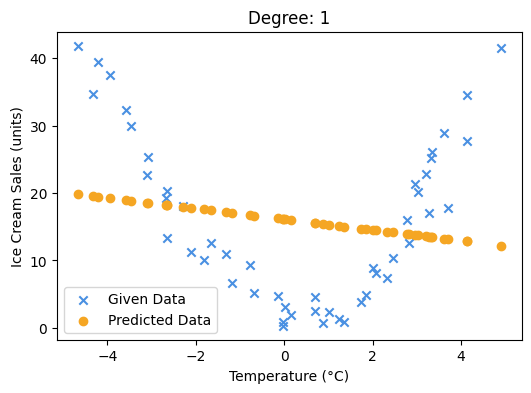

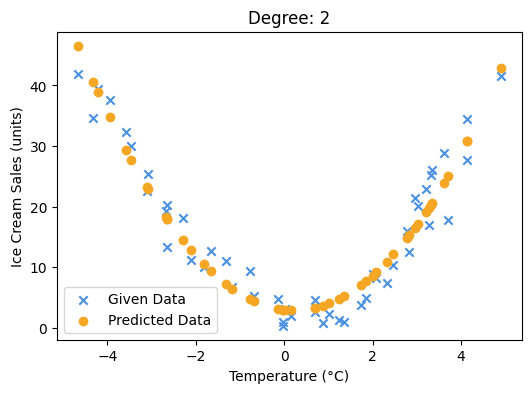

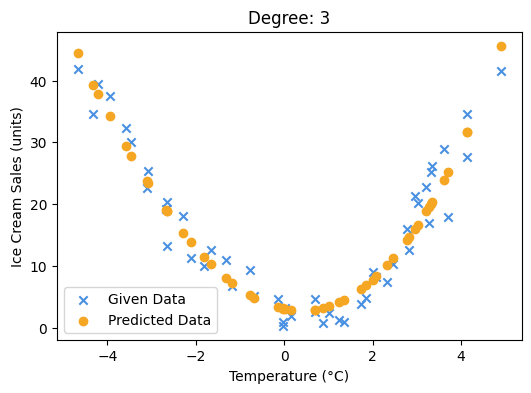

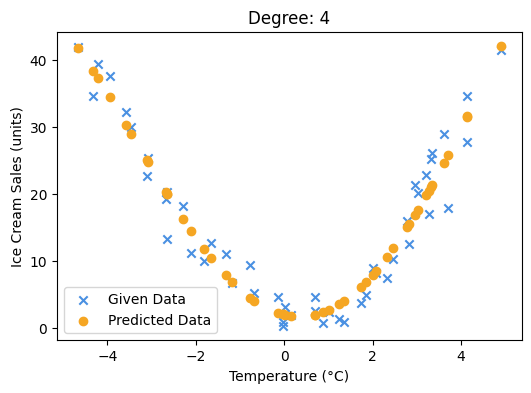

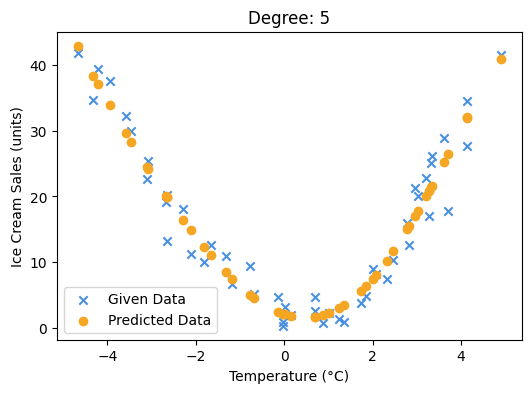

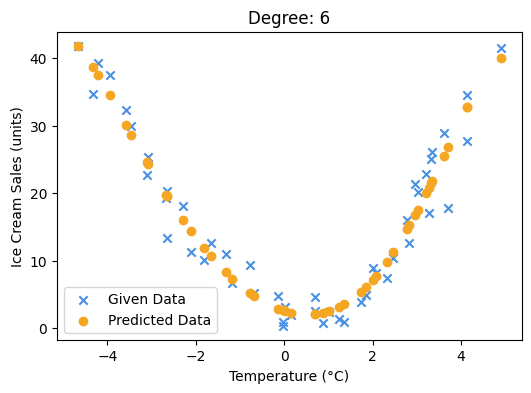

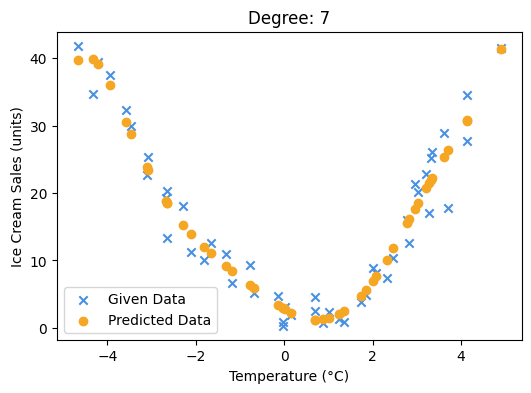

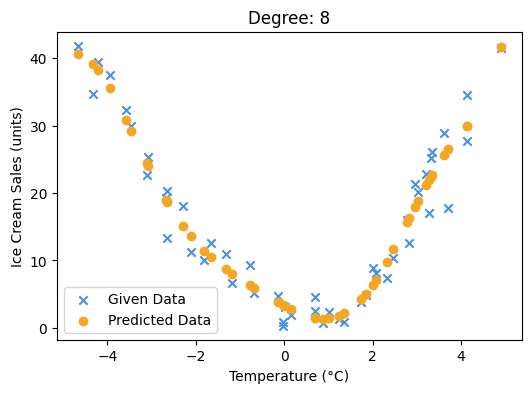

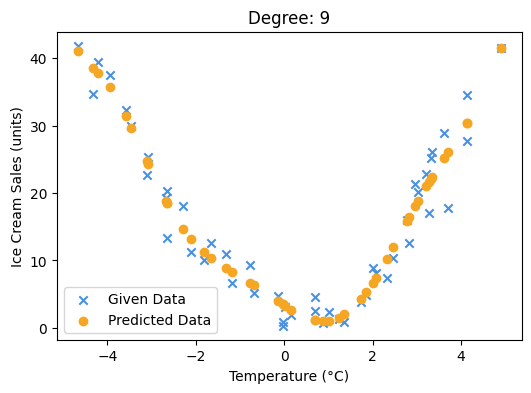

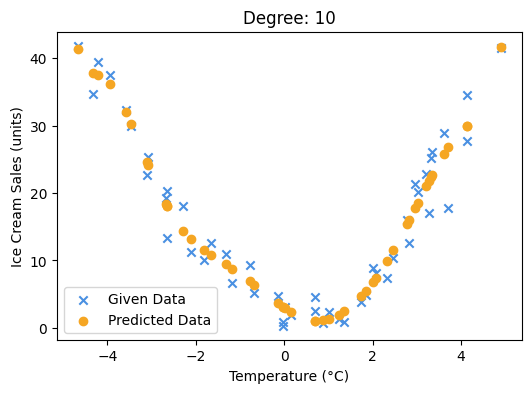

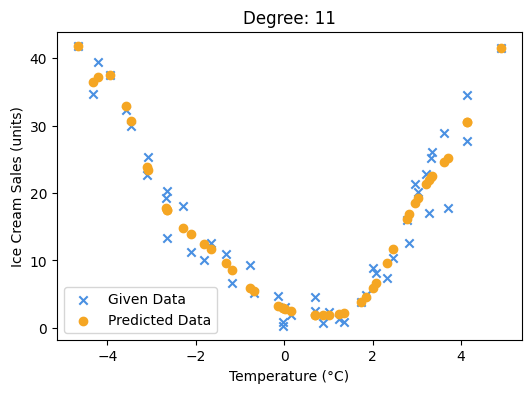

Degree 1 → MSE = 142.83040, R² = 0.03069
Degree 2 → MSE = 10.00322, R² = 0.93211
Degree 3 → MSE = 9.32724, R² = 0.93670
Degree 4 → MSE = 8.27453, R² = 0.94385
Degree 5 → MSE = 8.06265, R² = 0.94528
Degree 6 → MSE = 7.89861, R² = 0.94640
Degree 7 → MSE = 7.04528, R² = 0.95219
Degree 8 → MSE = 6.84356, R² = 0.95356
Degree 9 → MSE = 6.74864, R² = 0.95420
Degree 10 → MSE = 6.60098, R² = 0.95520
Degree 11 → MSE = 6.11459, R² = 0.95850


In [30]:
degrees = range(1,12)
errors = []

for d in degrees:
  poly = PolynomialFeatures(d)
  x_poly = poly.fit_transform(df[['Temperature (°C)']])
  scaler = StandardScaler()
  scaler.fit(x_poly)
  x_poly_stan = scaler.transform(x_poly)
  
  model = LinearRegression()
  model.fit(x_poly_stan, Y)
  output = model.predict(x_poly_stan)
  
  mse = mean_squared_error(Y, output)
  r2 = r2_score(Y, output)
  errors.append((d, mse, r2))
  
  fig = plt.figure(figsize=(6,4))
  plt.title(f"Degree: {d}")
  plt.scatter(X, Y, label='Given Data', marker='x', color='#4A90E2')
  plt.scatter(X, output, label='Predicted Data', color='#F5A623')
  plt.xlabel('Temperature (°C)')
  plt.ylabel('Ice Cream Sales (units)')
  plt.legend()
  plt.show()
  
  
for d, mse, r2 in errors:
    print(f"Degree {d} → MSE = {mse:.5f}, R² = {r2:.5f}")

#### Conclusion

1. Degree 1 is clearly bad
- MSE is extremely high (142)
- R² is almost 0.03
- So the model cannot capture curvature → Rejected

2. Degree 2 gives a huge improvement
- MSE drops to 10
- R² jumps to 0.93
- massive improvement and indicates the curve shape is captured.

3. Degrees 3–5 improve slightly
- MSE slowly decreases (9.3 → 8.0)
- R² increases only a little (0.936 → 0.945)
- small improvement, meaning:
  * Higher degrees are fitting noise instead of pattern.

4. Degrees 6–11
- This “improvement” is too small compared to increase in complexity.
- This is a sign of overfitting — the model memorizes the noisy data.

#### 🎯 Best Degree?
- Degree 2 or Degree 3
- Low error
- Simple model
- High interpretability
- Avoids overfitting
- Curve looks natural